# Comparación SVD vs ALS — Split Temporal

Carga los modelos ya entrenados y los evalúa con un **split temporal real**.

**Train:** Sep 2020 – Ene 2021 &nbsp;|&nbsp; **Test:** Feb 2021

**Métricas:**
 Métrica | Qué mide 

 **Precision@10** | De los 10 productos recomendados, ¿cuántos interactuó el usuario en el período de test? 

 **Recall@10** | De todos los productos que el usuario usó en test, ¿qué fracción aparece en el top-10? 
 
 **Coverage@10** | ¿Qué % del catálogo aparece en al menos una recomendación? (diversidad) 

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
K            = 10
N_SAMPLE     = 500   # usuarios Tier 2 a evaluar



---
## 1. Cargar datos de eventos

In [ ]:
from pathlib import Path

# Locate project root regardless of where the notebook server is launched from
_here = Path(os.path.abspath(""))
_project_root = next(
    p for p in [_here, _here.parent, _here.parent.parent]
    if (p / "data" / "final").exists()
)

# Cargar datos
df_events = pd.read_csv(_project_root / "data" / "final" / "events_final.csv")
df_events['event_time'] = pd.to_datetime(df_events['event_time'], utc=True)
# Asignar pesos a los eventos
weight_map = {'view': 1, 'cart': 2, 'purchase': 3}
df_events['peso'] = df_events['event_type'].map(weight_map).fillna(0)
# Filtrar eventos con peso > 0
df_interactions = (
    df_events
    .groupby(['user_id', 'product_id'], as_index=False)['peso']
    .sum()
)
df_interactions = df_interactions[df_interactions['peso'] > 0].reset_index(drop=True)
# Crear variable de tier por usuario
user_event_count = df_events.groupby('user_id').size().reset_index(name='event_count')
user_event_count['tier'] = user_event_count['event_count'].apply(lambda n: 1 if n <= 5 else 2)

#set de productos reales por usuario
ground_truth = (
    df_interactions.groupby('user_id')['product_id']
    .apply(set)
    .to_dict()
)

print(f'Eventos:            {df_events.shape[0]:,}')
print(f'Interacciones:      {df_interactions.shape[0]:,}')
print(f'Usuarios Tier 2:    {(user_event_count["tier"]==2).sum():,}')


---
## 2. Cargar ambos modelos

In [ ]:
_models_dir = _project_root / 'models'

# SVD
with open(_models_dir / 'svd_model.pkl', 'rb') as f:
    svd_model = pickle.load(f)
with open(_models_dir / 'user_profile.pkl', 'rb') as f:
    user_profile_svd = pickle.load(f)
with open(_models_dir / 'id_maps.pkl', 'rb') as f:
    id_maps = pickle.load(f)

# Catalogo ordenado por indice (igual en ambos modelos — mismo dataset)
unique_products = [id_maps['reverse_product_id_map'][i]
                   for i in range(len(id_maps['reverse_product_id_map']))]
N_ITEMS = len(unique_products)
N_USERS = len(user_profile_svd)

# ALS
with open(_models_dir / 'als_model.pkl', 'rb') as f:
    als_model = pickle.load(f)
with open(_models_dir / 'user_profile_als.pkl', 'rb') as f:
    user_profile_als = pickle.load(f)

print(f'Catalogo:           {N_ITEMS:,} productos')
print(f'Usuarios:           {N_USERS:,}')
print(f'SVD components:     {svd_model.components_.shape}')
print(f'ALS user_factors:   {als_model.user_factors.shape}')
print(f'ALS item_factors:   {als_model.item_factors.shape}')


Catalogo:           53,452 productos
Usuarios:           407,237
SVD components:     (50, 53452)
ALS user_factors:   (53452, 50)
ALS item_factors:   (407237, 50)


---
## 3. Funciones de scoring

In [ ]:
# ── ALS helpers (detectan la convencion de la version instalada) ──────────────
def _user_vec(model, user_idx):
    if model.user_factors.shape[0] == N_USERS:
        return model.user_factors[user_idx]
    return model.item_factors[user_idx]

def _item_matrix(model):
    if model.user_factors.shape[0] == N_ITEMS:
        return model.user_factors
    return model.item_factors


# ── Scoring por modelo ────────────────────────────────────────────────────────
# Ambas funciones reciben un perfil de usuario (vector de factores latentes) y devuelven un vector de scores para todos los items.
def score_svd(profile):
    """Vector de scores para todos los items (SVD)."""
    return svd_model.components_.T @ profile['latent_factors']

def score_als(profile):
    """Vector de scores para todos los items (ALS)."""
    return _item_matrix(als_model) @ _user_vec(als_model, profile['user_idx'])

print('Funciones de scoring listas.')

Funciones de scoring listas.


---
## 4. Split temporal — Train / Test

El ground truth es solo lo que el usuario **hizo en febrero**.  
Los modelos se **re-entrenan únicamente con datos de train** para no filtrar información futura.  
Solo se evalúan usuarios que aparecen en **ambos** períodos.

In [ ]:
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD as _SVD
import implicit as _implicit

# Separar train/test por tiempo (temporal holdout)
CUTOFF = pd.Timestamp('2021-02-01', tz='UTC')

# Construir interacciones ponderadas por usuario-producto para cada período
df_train = df_events[df_events['event_time'] < CUTOFF].copy()
df_test  = df_events[df_events['event_time'] >= CUTOFF].copy()

# Función para construir interacciones ponderadas por usuario-producto
def build_interactions(df):
    df = df.copy()
    df['peso'] = df['event_type'].map(weight_map).fillna(0)
    ints = df.groupby(['user_id', 'product_id'], as_index=False)['peso'].sum()
    return ints[ints['peso'] > 0].reset_index(drop=True)

# Construir interacciones para train y test
train_ints = build_interactions(df_train)
test_ints  = build_interactions(df_test)

# Solo usuarios que aparecen en AMBOS períodos
common_users = sorted(set(train_ints['user_id']) & set(test_ints['user_id']))
gt_temporal  = (
    test_ints[test_ints['user_id'].isin(set(common_users))]
    .groupby('user_id')['product_id'].apply(set)
    .to_dict()
)

print(f"Train: {len(df_train):,} eventos  ({df_train['event_time'].min().date()} → {df_train['event_time'].max().date()})")
print(f"Test:  {len(df_test):,} eventos   ({df_test['event_time'].min().date()} → {df_test['event_time'].max().date()})")
print(f"Usuarios comunes (en ambos períodos): {len(common_users):,}")

Train: 717,444 eventos  (2020-09-24 → 2021-01-31)
Test:  166,868 eventos   (2021-02-01 → 2021-02-28)
Usuarios comunes (en ambos períodos): 3,775


In [ ]:
# ── Mismo catálogo de productos → mantiene los índices del modelo original ──
prod_to_idx_t  = {p: i for i, p in enumerate(unique_products)}
all_train_users = sorted(train_ints['user_id'].unique())
utrain_to_idx   = {u: i for i, u in enumerate(all_train_users)}

# Construir matriz dispersa de interacciones para el período de entrenamiento (misma convención usuario×producto que el original)
rows_t = train_ints['user_id'].map(utrain_to_idx)
cols_t = train_ints['product_id'].map(prod_to_idx_t)
vals_t = train_ints['peso']
mask_t = rows_t.notna() & cols_t.notna()

# Solo filas/columnas con interacciones (usuarios/productos que aparecen en el período de entrenamiento)
train_matrix = csr_matrix(
    (vals_t[mask_t].values,
     (rows_t[mask_t].values.astype(int), cols_t[mask_t].values.astype(int))),
    shape=(len(all_train_users), N_ITEMS)
)

# ── Re-entrenar SVD ──────────────────────────────────────────────────────────
N_COMP        = svd_model.components_.shape[0]
svd_t         = _SVD(n_components=N_COMP, random_state=RANDOM_STATE)
user_latent_t = svd_t.fit_transform(train_matrix)   # (n_train_users, N_COMP)

# ── Re-entrenar ALS (misma convención producto×usuario que el original) ──────
als_t = _implicit.als.AlternatingLeastSquares(
    factors=50, regularization=0.01, iterations=20, random_state=RANDOM_STATE)
als_t.fit(train_matrix.T.tocsr())

print(f'Matriz train:    {train_matrix.shape}')
print(f'SVD temporal:    components={svd_t.components_.shape}')
print(f'ALS temporal:    user_factors={als_t.user_factors.shape}, item_factors={als_t.item_factors.shape}')

  0%|          | 0/20 [00:00<?, ?it/s]

Matriz train:    (336408, 53452)
SVD temporal:    components=(50, 53452)
ALS temporal:    user_factors=(53452, 50), item_factors=(336408, 50)


In [ ]:
# ── Evaluación ───────────────────────────────────────────────────────────────

# Para cada usuario común, generar recomendaciones con ambos modelos y comparar con el ground truth del período de test.
p_svd_t, r_svd_t = [], []
p_als_t, r_als_t = [], []
recs_svd_t, recs_als_t = set(), set()

# Evaluar solo usuarios comunes (con interacciones en ambos períodos)
for uid in common_users:
    idx      = utrain_to_idx.get(uid)
    relevant = gt_temporal.get(uid, set())
    if idx is None or not relevant:
        continue

    # ── SVD temporal ─────────────────────────────────────────────────────
    sc_svd  = svd_t.components_.T @ user_latent_t[idx]
    top_svd = {unique_products[i] for i in np.argpartition(sc_svd, -K)[-K:]}
    hits    = len(top_svd & relevant)
    p_svd_t.append(hits / K)
    r_svd_t.append(hits / len(relevant))
    recs_svd_t.update(top_svd)

    # ── ALS temporal ─────────────────────────────────────────────────────
    if als_t.user_factors.shape[0] == N_ITEMS:
        item_mat_t = als_t.user_factors
        user_vec_t = als_t.item_factors[idx]
    else:
        item_mat_t = als_t.item_factors
        user_vec_t = als_t.user_factors[idx]
    sc_als  = item_mat_t @ user_vec_t
    top_als = {unique_products[i] for i in np.argpartition(sc_als, -K)[-K:]}
    hits    = len(top_als & relevant)
    p_als_t.append(hits / K)
    r_als_t.append(hits / len(relevant))
    recs_als_t.update(top_als)

# Resultados
res_svd_t = {f'Precision@{K}': float(np.mean(p_svd_t)),
             f'Recall@{K}':    float(np.mean(r_svd_t)),
             f'Coverage@{K}':  len(recs_svd_t) / N_ITEMS}
res_als_t = {f'Precision@{K}': float(np.mean(p_als_t)),
             f'Recall@{K}':    float(np.mean(r_als_t)),
             f'Coverage@{K}':  len(recs_als_t) / N_ITEMS}

df_res = pd.DataFrame({'SVD': res_svd_t, 'ALS': res_als_t}).T.round(4)
print(f'Usuarios evaluados: {len(p_svd_t):,}\n')
print(df_res)


Usuarios evaluados: 3,775

     Precision@10  Recall@10  Coverage@10
SVD        0.0276     0.1628       0.0057
ALS        0.0428     0.2669       0.0102


---
## 6. Resultados finales

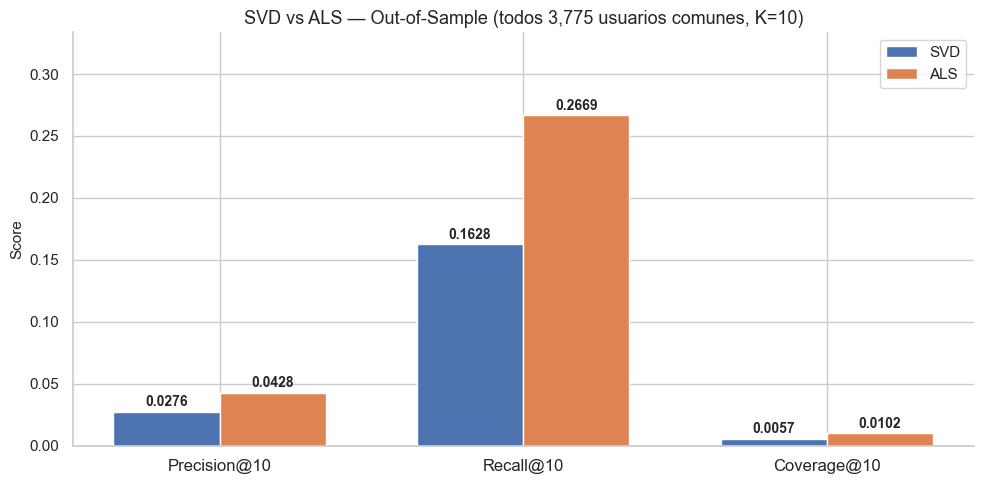

In [ ]:
#── Gráficos comparativos ───────────────────────────────────────────────────
labels  = list(res_svd_t.keys())
x       = np.arange(len(labels))
width   = 0.35
col_svd, col_als = '#4C72B0', '#DD8452'

fig, ax = plt.subplots(figsize=(10, 5))
bars_svd = ax.bar(x - width/2, list(res_svd_t.values()), width, label='SVD', color=col_svd)
bars_als = ax.bar(x + width/2, list(res_als_t.values()), width, label='ALS', color=col_als)

# Agregar etiquetas de valor encima de cada barra
for bars, vals in [(bars_svd, list(res_svd_t.values())), (bars_als, list(res_als_t.values()))]:
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(f'SVD vs ALS — Out-of-Sample (todos {len(p_svd_t):,} usuarios comunes, K={K})', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, max(list(res_svd_t.values()) + list(res_als_t.values())) * 1.25)
sns.despine()
plt.tight_layout()
plt.show()


---
## 7. ¿Vale la pena filtrar usuarios activos (>5 eventos en train)?

Mismos modelos, misma evaluación temporal, pero ahora **solo con usuarios que tuvieron más de 5 eventos en el período de train**.  
Así vemos si las métricas suben y decidimos si conviene reentrenar los modelos con ese filtro.

In [22]:
# Usuarios con >5 eventos en el período de train
train_event_count = df_train.groupby('user_id').size().reset_index(name='n_train')
active_set = set(train_event_count[train_event_count['n_train'] > 5]['user_id'])
active_common = [u for u in common_users if u in active_set]

print(f'Usuarios comunes totales:       {len(common_users):,}')
print(f'Usuarios activos >5 en train:   {len(active_common):,}')
print(f'Descartados:                    {len(common_users) - len(active_common):,}')


Usuarios comunes totales:       3,775
Usuarios activos >5 en train:   1,063
Descartados:                    2,712


In [ ]:
# Evaluar solo usuarios comunes activos (con >5 eventos en train)
p_svd_a, r_svd_a = [], []
p_als_a, r_als_a = [], []
recs_svd_a, recs_als_a = set(), set()

# Para cada usuario común activo, generar recomendaciones con ambos modelos y comparar con el ground truth del período de test.
for uid in active_common:
    idx      = utrain_to_idx.get(uid)
    relevant = gt_temporal.get(uid, set())
    if idx is None or not relevant:
        continue

    # SVD
    sc_svd  = svd_t.components_.T @ user_latent_t[idx]
    top_svd = {unique_products[i] for i in np.argpartition(sc_svd, -K)[-K:]}
    hits    = len(top_svd & relevant)
    p_svd_a.append(hits / K)
    r_svd_a.append(hits / len(relevant))
    recs_svd_a.update(top_svd)

    # ALS
    if als_t.user_factors.shape[0] == N_ITEMS:
        item_mat_a = als_t.user_factors
        user_vec_a = als_t.item_factors[idx]
    else:
        item_mat_a = als_t.item_factors
        user_vec_a = als_t.user_factors[idx]
    sc_als  = item_mat_a @ user_vec_a
    top_als = {unique_products[i] for i in np.argpartition(sc_als, -K)[-K:]}
    hits    = len(top_als & relevant)
    p_als_a.append(hits / K)
    r_als_a.append(hits / len(relevant))
    recs_als_a.update(top_als)

# Resultados
res_svd_a = {f'Precision@{K}': float(np.mean(p_svd_a)),
             f'Recall@{K}':    float(np.mean(r_svd_a)),
             f'Coverage@{K}':  len(recs_svd_a) / N_ITEMS}
res_als_a = {f'Precision@{K}': float(np.mean(p_als_a)),
             f'Recall@{K}':    float(np.mean(r_als_a)),
             f'Coverage@{K}':  len(recs_als_a) / N_ITEMS}

# Comparación final
df_cmp = pd.DataFrame({
    f'SVD  todos ({len(p_svd_t):,} usuarios)':    res_svd_t,
    f'ALS  todos ({len(p_als_t):,} usuarios)':    res_als_t,
    f'SVD  activos ({len(p_svd_a):,} usuarios)':  res_svd_a,
    f'ALS  activos ({len(p_als_a):,} usuarios)':  res_als_a,
}).T.round(4)

print(df_cmp)


                               Precision@10  Recall@10  Coverage@10
SVD  todos (3,775 usuarios)          0.0276     0.1628       0.0057
ALS  todos (3,775 usuarios)          0.0428     0.2669       0.0102
SVD  activos (1,063 usuarios)        0.0492     0.2431       0.0055
ALS  activos (1,063 usuarios)        0.0749     0.4037       0.0091


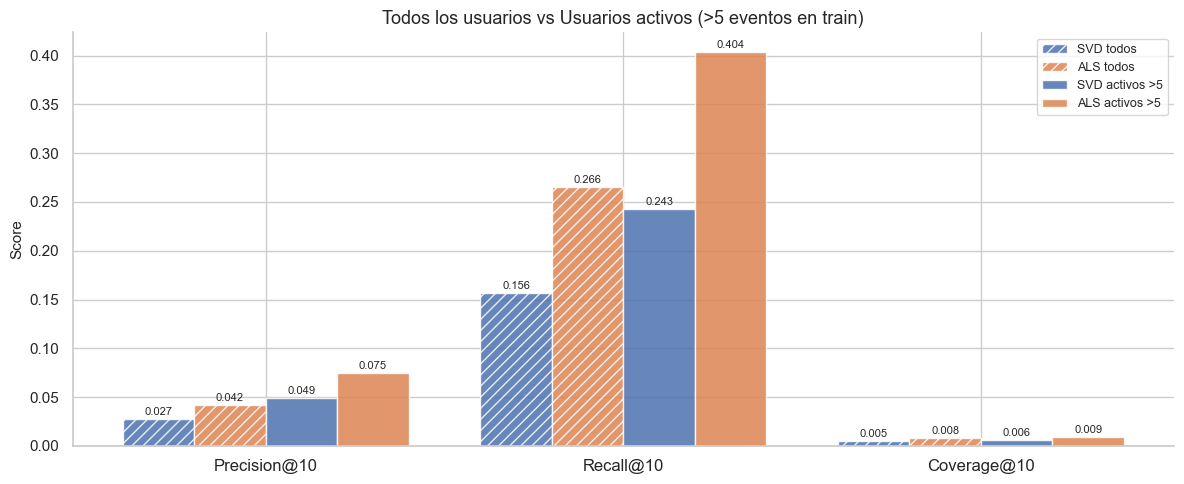

In [ ]:

grupos  = ['todos', 'todos', 'activos >5', 'activos >5']
modelos = ['SVD', 'ALS', 'SVD', 'ALS']
resultados = [res_svd_t, res_als_t, res_svd_a, res_als_a]
colores = ['#4C72B0', '#DD8452', '#4C72B0', '#DD8452']
hatches = ['///', '///', '', '']

# Gráfico comparativo de métricas por grupo/modelo
metricas_plot = list(res_svd_t.keys())
n = len(metricas_plot)
x = np.arange(n)
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
for i, (grupo, modelo, res, color, hatch) in enumerate(zip(grupos, modelos, resultados, colores, hatches)):
    vals = [res[m] for m in metricas_plot]
    bars = ax.bar(x + (i - 1.5) * width, vals, width,
                  label=f'{modelo} {grupo}', color=color, hatch=hatch, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metricas_plot, fontsize=12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Todos los usuarios vs Usuarios activos (>5 eventos en train)', fontsize=13)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


---
## 8. Conclusión — ¿Qué hacemos con esto?

### ¿Qué aprendimos?

**ALS le gana a SVD** en todas las métricas, con todos los usuarios y con los activos. Eso ya lo sabíamos.

**Filtrar a usuarios activos (>5 eventos) sube las métricas**, y tiene sentido:  
un usuario que vio 2 productos en 5 meses no le da suficiente información al modelo para hacer una buena recomendación.

---

### El trade-off

| | Evaluar con todos | Evaluar solo activos |
|---|---|---|
| **Usuarios cubiertos** | Más (incluye los poco activos) | Menos |
| **Métricas** | Más bajas (más ruido) | Más altas (más justas) |
| **Representa la realidad** | Sí, pero incluye casos difíciles | Sí, los usuarios que más usan la app |

---

### ¿Vale la pena reentrenar los modelos filtrando usuarios con poco historial?

**No necesariamente.** El modelo ya maneja esto de otra forma:
- Usuarios con ≤5 eventos → van a **cold start** (recomendaciones por popularidad)
- Usuarios con >5 eventos → van al **modelo colaborativo** (ALS)

O sea, los usuarios "poco activos" ya están separados antes de llegar al modelo. No hace falta reentrenar.

**Lo que sí conviene** es reportar las métricas sobre usuarios activos, porque esos son los que el modelo realmente atiende en producción.